In [1]:
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

np.random.seed(42)

In [ ]:
###Synthetic Dataset###

In [4]:
NUM_MERCHANTS = 200
NUM_ORDERS = 40000
START_DATE = datetime(2024, 1, 1)
merchant_profiles = []
for m in range(NUM_MERCHANTS):
    base_kpt = np.random.normal(22, 3)
    variance = np.random.uniform(2, 5)
    bias = np.random.uniform(1, 5)  # Increased bias
    merchant_profiles.append([m, base_kpt, variance, bias])
merchant_df = pd.DataFrame(
    merchant_profiles,
    columns=["merchant_id", "base_kpt", "variance", "merchant_bias"]
)
orders = []
for i in range(NUM_ORDERS):
    merchant = merchant_df.sample(1).iloc[0]
    order_time = START_DATE + timedelta(minutes=random.randint(0, 60*24*30))
    hour = order_time.hour
    # Peak detection
    peak = 1 if (12 <= hour <= 14 or 19 <= hour <= 22) else 0
    rush_factor = 1.5 if peak else 1.0
    lambda_orders = 8 if peak else 3
    active_orders = np.random.poisson(lambda_orders)
    true_kpt = np.random.normal(
        merchant["base_kpt"],
        merchant["variance"]
    )
    true_kpt = max(10, min(45, true_kpt)) * rush_factor
    dispatch_delay = random.randint(5, 10)
    travel_time = random.randint(5, 15)
    rider_arrival_delay = dispatch_delay + travel_time
    rider_arrival = order_time + timedelta(minutes=rider_arrival_delay)
    true_ready_time = order_time + timedelta(minutes=true_kpt)

    # Increased rider influence probability
    if random.random() < 0.4:
        for_time = rider_arrival + timedelta(minutes=np.random.uniform(0,3))
    else:
        for_time = true_ready_time + timedelta(minutes=merchant["merchant_bias"] + peak*2)
    observed_kpt = (for_time - order_time).total_seconds() / 60
    orders.append([
        i,
        merchant["merchant_id"],
        true_kpt,
        observed_kpt,
        active_orders,
        rider_arrival_delay,
        peak
    ])

df = pd.DataFrame(orders, columns=[
    "order_id",
    "merchant_id",
    "true_kpt",
    "observed_kpt",
    "active_orders",
    "rider_arrival_delay",
    "peak"
])

df.head()

,order_id,merchant_id,true_kpt,observed_kpt,active_orders,rider_arrival_delay,peak
0,0,131.0,21.413994,16.921976,5,15,0
1,1,122.0,17.581375,18.756070,3,18,0
2,2,124.0,34.587486,41.399157,8,18,1
3,3,86.0,20.119847,24.556353,3,15,0
4,4,27.0,30.661733,34.582488,8,13,1


In [23]:
df.to_csv("synthetic_kpt_dataset.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


In [25]:
import os
print(os.getcwd())

C:\Users\nithi


In [3]:
# Estimate bias as difference between observed & rider delay patterns
df["delay_gap"] = df["observed_kpt"] - df["rider_arrival_delay"]
merchant_bias_est = df.groupby("merchant_id")["delay_gap"].median().reset_index()
merchant_bias_est.columns = ["merchant_id", "estimated_bias"]
df = df.merge(merchant_bias_est, on="merchant_id")
df["bias_corrected_kpt"] = df["observed_kpt"] - df["estimated_bias"]
df[["observed_kpt", "bias_corrected_kpt"]].head()

,observed_kpt,bias_corrected_kpt
0,22.512838,17.673107
1,24.877038,21.213058
2,48.688755,46.189366
3,11.794982,7.234969
4,17.437270,10.677633


In [10]:
###Robust Estimation (Trimmed Mean Approach)

lower = df["bias_corrected_kpt"].quantile(0.05)
upper = df["bias_corrected_kpt"].quantile(0.95)
df["robust_kpt"] = df["bias_corrected_kpt"].clip(lower, upper)

In [6]:
print(df.columns)

Index(['order_id', 'merchant_id', 'true_kpt', 'observed_kpt', 'active_orders',
       'rider_arrival_delay', 'peak'],
      dtype='object')


In [7]:
# Create delay gap
df["delay_gap"] = df["observed_kpt"] - df["rider_arrival_delay"]

# Estimate merchant bias
merchant_bias_est = df.groupby("merchant_id")["delay_gap"].median().reset_index()
merchant_bias_est.columns = ["merchant_id", "estimated_bias"]

# Merge bias
df = df.merge(merchant_bias_est, on="merchant_id", how="left")

# Create bias corrected KPT
df["bias_corrected_kpt"] = df["observed_kpt"] - df["estimated_bias"]

df[["observed_kpt", "bias_corrected_kpt"]].head()

,observed_kpt,bias_corrected_kpt
0,16.921976,10.596643
1,18.756070,16.159109
2,41.399157,35.894298
3,24.556353,21.708946
4,34.582488,28.012022


In [8]:
print(df.columns)

Index(['order_id', 'merchant_id', 'true_kpt', 'observed_kpt', 'active_orders',
       'rider_arrival_delay', 'peak', 'delay_gap', 'estimated_bias',
       'bias_corrected_kpt'],
      dtype='object')


In [11]:
###Hypothesis Testing###

corr, p_value = pearsonr(df["observed_kpt"], df["rider_arrival_delay"])
print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: 0.184
P-value: 1.7177683766434432e-301


In [12]:
###Smarter Rush Adjustment###

df["kitchen_load_index"] = df["active_orders"] / df["active_orders"].max()
# Adjust only during peak
df["rush_adjusted_kpt"] = np.where(
    df["peak"] == 1,
    df["robust_kpt"] * (1 + df["kitchen_load_index"] * 0.2),
    df["robust_kpt"]
)

In [13]:
###Bayesian Updating###
prior = df["robust_kpt"].median()
df["bayesian_kpt"] = (
    0.6 * df["robust_kpt"] +
    0.4 * df["rush_adjusted_kpt"]
)

In [14]:
###Merchant Reliability Scoring###
merchant_variance = df.groupby("merchant_id")["observed_kpt"].var().reset_index()
merchant_variance.columns = ["merchant_id", "merchant_variance"]
df = df.merge(merchant_variance, on="merchant_id")
df["merchant_reliability_score"] = 1 / (1 + df["merchant_variance"])

In [15]:
def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))
raw_mae = mae(df["true_kpt"], df["observed_kpt"])
bayesian_mae = mae(df["true_kpt"], df["bayesian_kpt"])
improvement = ((raw_mae - bayesian_mae) / raw_mae) * 100
print("Raw MAE:", raw_mae)
print("Final Bayesian MAE:", bayesian_mae)
print("Percentage Improvement:", round(improvement,2), "%")

Raw MAE: 5.295043899240354
Final Bayesian MAE: 5.663684447808145
Percentage Improvement: -6.96 %


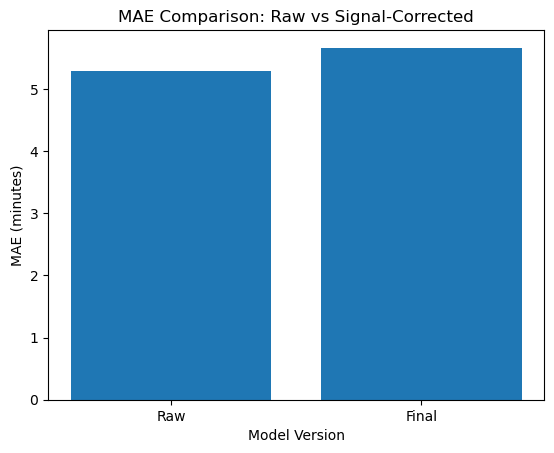

In [16]:
###MAE Comparison Chart###
plt.figure()
plt.bar(["Raw", "Final"], [raw_mae, bayesian_mae])
plt.title("MAE Comparison: Raw vs Signal-Corrected")
plt.xlabel("Model Version")
plt.ylabel("MAE (minutes)")
plt.show()

In [17]:
def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))
def p90_error(actual, predicted):
    return np.percentile(np.abs(actual - predicted), 90)
print("MAE Comparison")
print("Raw:", mae(df["true_kpt"], df["observed_kpt"]))
print("Bias Corrected:", mae(df["true_kpt"], df["bias_corrected_kpt"]))
print("Robust:", mae(df["true_kpt"], df["robust_kpt"]))
print("Rush Adjusted:", mae(df["true_kpt"], df["rush_adjusted_kpt"]))
print("Bayesian:", mae(df["true_kpt"], df["bayesian_kpt"]))

MAE Comparison
Raw: 5.295043899240354
Bias Corrected: 5.670594007252472
Robust: 5.689933320317233
Rush Adjusted: 5.694562596145655
Bayesian: 5.663684447808145


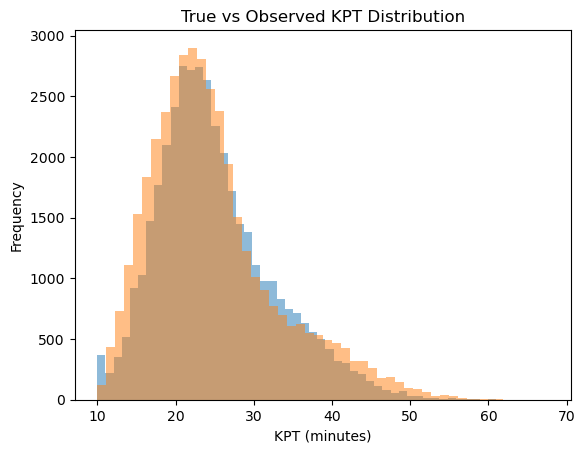

In [18]:
##True vs Observed Distribution##

plt.figure()
plt.hist(df["true_kpt"], bins=50, alpha=0.5)
plt.hist(df["observed_kpt"], bins=50, alpha=0.5)
plt.title("True vs Observed KPT Distribution")
plt.xlabel("KPT (minutes)")
plt.ylabel("Frequency")
plt.show()

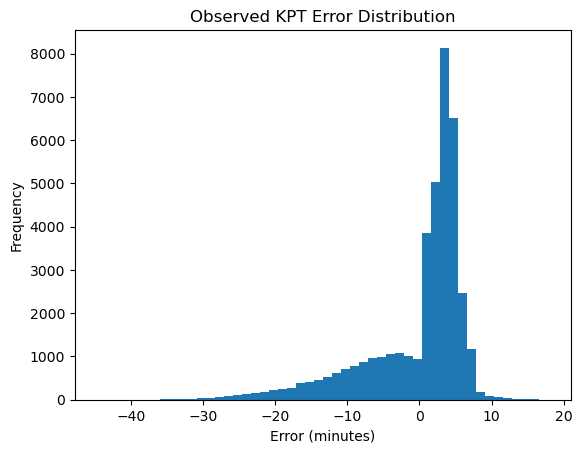

In [19]:
###Error Distribution###
plt.figure()
error = df["observed_kpt"] - df["true_kpt"]
plt.hist(error, bins=50)
plt.title("Observed KPT Error Distribution")
plt.xlabel("Error (minutes)")
plt.ylabel("Frequency")
plt.show()

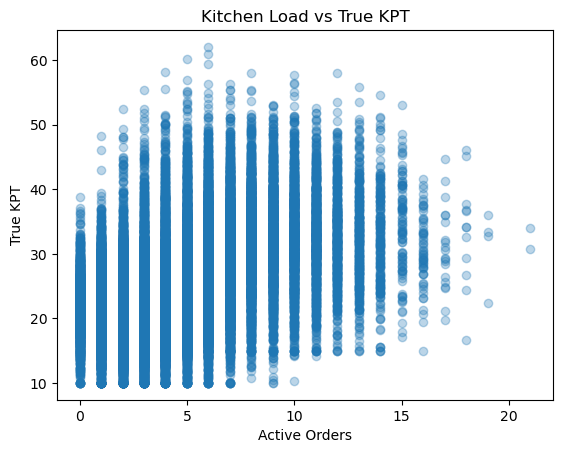

In [20]:
###Kitchen Load vs True KPT###

plt.figure()
plt.scatter(df["active_orders"], df["true_kpt"], alpha=0.3)
plt.title("Kitchen Load vs True KPT")
plt.xlabel("Active Orders")
plt.ylabel("True KPT")
plt.show()

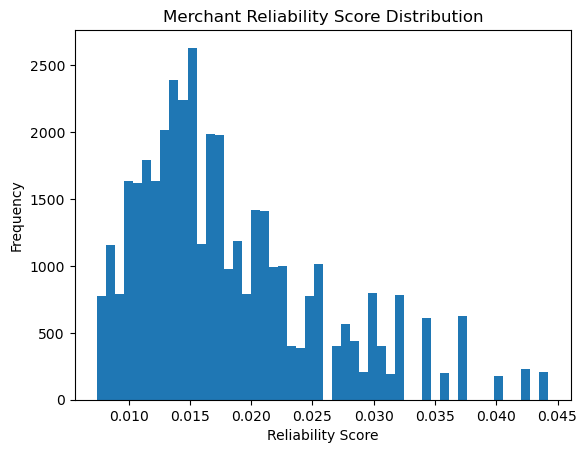

In [21]:
###Merchant Reliability Distribution###
plt.figure()
plt.hist(df["merchant_reliability_score"], bins=50)
plt.title("Merchant Reliability Score Distribution")
plt.xlabel("Reliability Score")
plt.ylabel("Frequency")
plt.show()